# Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [19]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import scipy.stats as stats
from scipy.stats import ttest_ind
from sqlalchemy import URL, create_engine

warnings.filterwarnings("ignore")

In [35]:
DB_CONFIG = {
    "host": "localhost",
    "database": "ipldatabase",
    "user": "postgres",
    "password": "vk@123456#",
    "port": 5432,
}

db_url = URL.create(
    "postgresql+psycopg2",
    username=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"],
    database=DB_CONFIG["database"],
)

engine = create_engine(db_url)
conn = psycopg2.connect(**DB_CONFIG)

final_table = pd.read_sql_query("SELECT * FROM final_table", engine)

print("Database connected successfully.")
print("final_table loaded:", final_table.shape)

Database connected successfully.
final_table loaded: (244837, 29)


In [36]:
final_table.dtypes

match_id                      str
inning                      int64
over                        int64
ball                        int64
batter                        str
bowler                        str
non_striker                   str
batsman_runs                int64
extra_runs                  int64
total_runs                  int64
extras_type                   str
season                        str
city                          str
date               datetime64[us]
match_type                    str
player_of_match               str
venue                         str
team1                         str
team2                         str
toss_winner                   str
toss_decision                 str
winner                        str
result                        str
result_margin             float64
target_runs               float64
target_overs              float64
super_over                    str
umpire1                       str
umpire2                       str
dtype: object

In [37]:
match_df = final_table.drop_duplicates(subset = 'match_id')
toss_winners = match_df['toss_winner'].value_counts()
print(toss_winners)
print(match_df['toss_decision'].value_counts())
winners = match_df['winner'].value_counts()
print(winners)
print(match_df['venue'].value_counts())
match_played = pd.concat([
    match_df['team1'],
    match_df['team2']
]).value_counts()
print(match_played)


toss_winner
Mumbai Indians                 135
Delhi Capitals                 123
Kolkata Knight Riders          118
Chennai Super Kings            115
Royal Challengers Bangalore    111
Rajasthan Royals               111
Punjab Kings                   103
Sunrisers Hyderabad             77
Deccan Chargers                 43
Rising Pune Supergiants         33
Gujarat Titans                  22
Lucknow Super Giants            19
Gujarat Lions                   15
Name: count, dtype: int64
toss_decision
field    661
bat      364
Name: count, dtype: int64
winner
Mumbai Indians                 139
Chennai Super Kings            130
Kolkata Knight Riders          128
Royal Challengers Bangalore    114
Rajasthan Royals               108
Delhi Capitals                 105
Punjab Kings                   102
Sunrisers Hyderabad             80
Deccan Chargers                 28
Gujarat Titans                  28
Rising Pune Supergiants         26
Lucknow Super Giants            24
Gujarat Lions 

In [38]:
percetage_winning = (winners/match_played)*100
print("% winning")
print(percetage_winning)

% winning
winner
Chennai Super Kings            58.558559
Deccan Chargers                37.837838
Delhi Capitals                 45.258621
Gujarat Lions                  43.333333
Gujarat Titans                 62.222222
Kolkata Knight Riders          53.112033
Lucknow Super Giants           55.813953
Mumbai Indians                 56.048387
Punjab Kings                   43.965517
Rajasthan Royals               52.427184
Rising Pune Supergiants        35.135135
Royal Challengers Bangalore    48.305085
Sunrisers Hyderabad            47.904192
Name: count, dtype: float64


In [39]:
toss_match_winner = match_df[
    match_df['toss_winner'] == match_df['winner']
]
both_win = toss_match_winner['toss_winner'].value_counts()
print(both_win)
percetage_toss_and_match_winning = (both_win/toss_winners)*100 
print(" team % who wins the both match and toss")
print(percetage_toss_and_match_winning)


toss_winner
Mumbai Indians                 75
Chennai Super Kings            72
Kolkata Knight Riders          68
Delhi Capitals                 59
Rajasthan Royals               58
Royal Challengers Bangalore    57
Punjab Kings                   41
Sunrisers Hyderabad            32
Deccan Chargers                19
Gujarat Titans                 14
Rising Pune Supergiants        11
Gujarat Lions                  10
Lucknow Super Giants           10
Name: count, dtype: int64
 team % who wins the both match and toss
toss_winner
Chennai Super Kings            62.608696
Deccan Chargers                44.186047
Delhi Capitals                 47.967480
Gujarat Lions                  66.666667
Gujarat Titans                 63.636364
Kolkata Knight Riders          57.627119
Lucknow Super Giants           52.631579
Mumbai Indians                 55.555556
Punjab Kings                   39.805825
Rajasthan Royals               52.252252
Rising Pune Supergiants        33.333333
Royal Challenger

 analysis per season 


In [25]:
season_winners = match_df.sort_values('match_id').groupby('season').tail(1)
season_winners = season_winners[['season', 'winner']]
print(season_winners)

       season                 winner
143561   2017         Mumbai Indians
157851   2018    Chennai Super Kings
171876   2019         Mumbai Indians
177402   2020         Delhi Capitals
191824   2021    Chennai Super Kings
209756   2022         Gujarat Titans
227518   2023    Chennai Super Kings
244653   2024  Kolkata Knight Riders
13287    2008       Rajasthan Royals
26696    2009        Deccan Chargers
41359    2010    Chennai Super Kings
55121    2011    Chennai Super Kings
72882    2012  Kolkata Knight Riders
91046    2013         Mumbai Indians
102213   2014  Kolkata Knight Riders
115485   2015         Mumbai Indians
129695   2016    Sunrisers Hyderabad


In [26]:
match_per_season = match_df.groupby("season")['match_id'].count().reset_index()
match_per_season.columns = ["season", "matches"]
print(match_per_season)

   season  matches
0    2008       58
1    2009       57
2    2010       60
3    2011       58
4    2012       74
5    2013       76
6    2014       47
7    2015       57
8    2016       60
9    2017       59
10   2018       60
11   2019       59
12   2020       22
13   2021       60
14   2022       74
15   2023       73
16   2024       71


In [27]:
pom_season = (
    match_df.groupby(['season', 'player_of_match'])
    .size()
    .reset_index(name='awards')
)

top_pom_per_season = (
    pom_season.sort_values('awards', ascending=False)
    .groupby('season')
    .head(1)
)

print(top_pom_per_season)

    season  player_of_match  awards
370   2016          V Kohli       5
28    2008         SE Marsh       5
179   2012         CH Gayle       5
244   2013       MEK Hussey       5
130   2011         CH Gayle       5
666   2023      YBK Jaiswal       4
459   2019       AD Russell       4
446   2018      Rashid Khan       4
551   2021       RD Gaikwad       4
581   2022    Kuldeep Yadav       4
121   2010     SR Tendulkar       4
303   2015        DA Warner       4
80    2009        YK Pathan       3
668   2024  Abhishek Sharma       3
376   2017        BA Stokes       3
286   2014       RV Uthappa       3
500   2020        BA Stokes       2


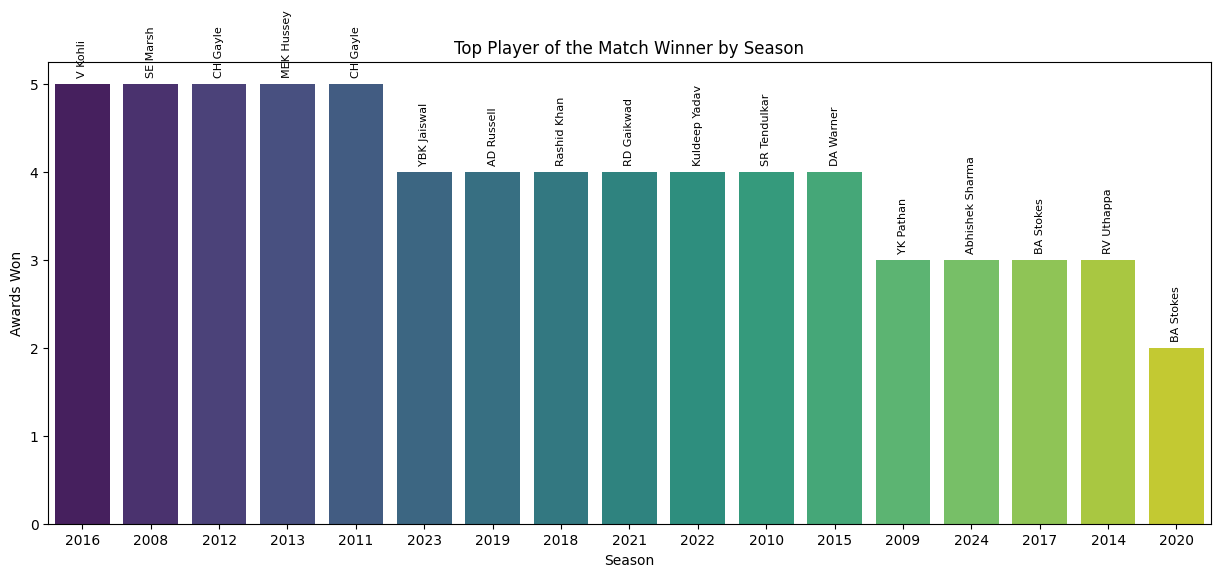

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))

ax = sns.barplot(
    data=top_pom_per_season,
    x='season',
    y='awards',
    palette='viridis'
)

for i, player in enumerate(top_pom_per_season['player_of_match']):
    ax.text(
        i,
        top_pom_per_season.iloc[i]['awards'] + 0.1,
        player,
        ha='center',
        fontsize=8,
        rotation=90
    )

plt.title('Top Player of the Match Winner by Season')
plt.xlabel('Season')
plt.ylabel('Awards Won')

plt.show()

venue analysis 

In [29]:
city_match = (match_df['city'].value_counts().reset_index())
city_match.columns = ['city','matches']
print(city_match.head(10))

         city  matches
0      Mumbai      171
1     Kolkata       92
2       Delhi       88
3     Chennai       84
4   Hyderabad       77
5   Bangalore       62
6  Chandigarh       61
7      Jaipur       56
8        Pune       51
9   Abu Dhabi       37


In [30]:
venue_team_wins = (match_df.groupby(['venue','winner']).size().reset_index(name = 'wins'))
print(venue_team_wins.head(10))


                         venue                       winner  wins
0         Arun Jaitley Stadium          Chennai Super Kings     1
1         Arun Jaitley Stadium               Delhi Capitals     8
2         Arun Jaitley Stadium               Mumbai Indians     1
3         Arun Jaitley Stadium                 Punjab Kings     1
4         Arun Jaitley Stadium  Royal Challengers Bangalore     1
5         Arun Jaitley Stadium          Sunrisers Hyderabad     2
6  Arun Jaitley Stadium, Delhi          Chennai Super Kings     2
7  Arun Jaitley Stadium, Delhi               Delhi Capitals     6
8  Arun Jaitley Stadium, Delhi               Gujarat Titans     1
9  Arun Jaitley Stadium, Delhi               Mumbai Indians     3


In [31]:
top_team_per_venue = (
    venue_team_wins
    .sort_values('wins', ascending=False)
    .groupby('venue')
    .head(1)
)

print(top_team_per_venue.head(5))

                               venue                       winner  wins
80                      Eden Gardens        Kolkata Knight Riders    45
333                 Wankhede Stadium               Mumbai Indians    42
158  MA Chidambaram Stadium, Chepauk          Chennai Super Kings    32
280           Sawai Mansingh Stadium             Rajasthan Royals    31
142            M Chinnaswamy Stadium  Royal Challengers Bangalore    28


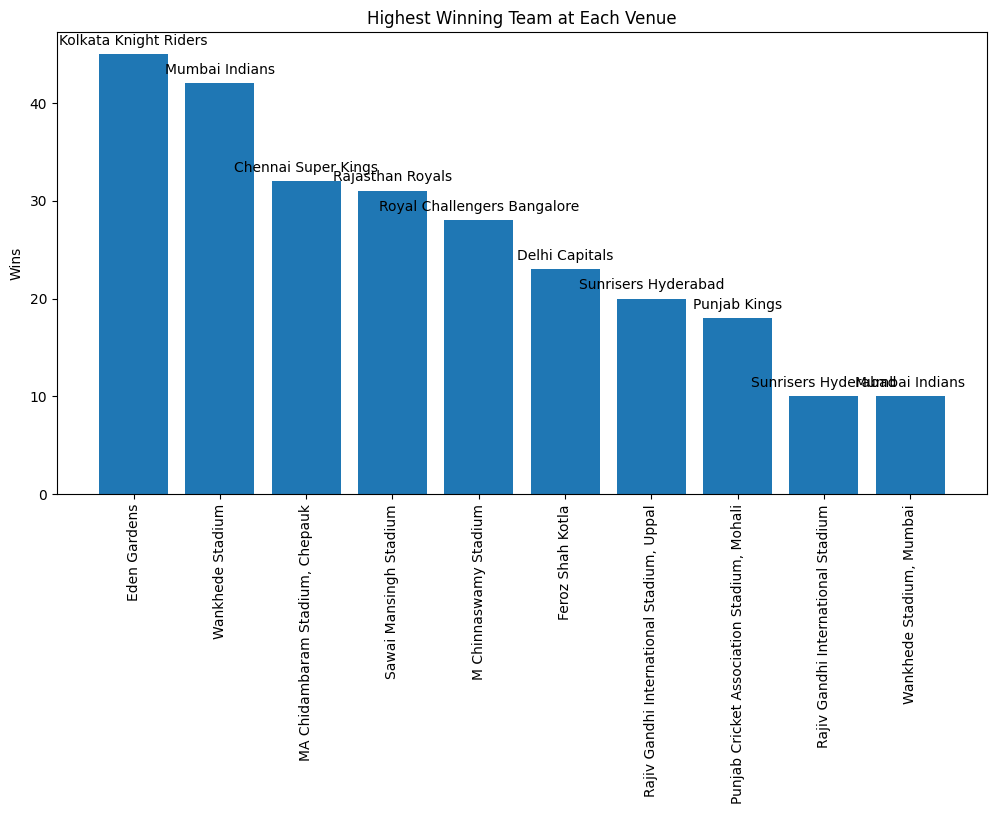

In [32]:
top10 = (
    top_team_per_venue
    .sort_values('wins', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top10['venue'],
    top10['wins']
)

for bar, team in zip(bars, top10['winner']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        team,
        ha='center'
    )

plt.xticks(rotation=90)

plt.title('Highest Winning Team at Each Venue')
plt.ylabel('Wins')

plt.show()

result analysis 

In [33]:
super_over = (match_df['super_over'].value_counts().reset_index())
print(super_over)

  super_over  count
0          N   1014
1          Y     11


In [ ]:
avg_margin = (match_df[match_df['result']=='runs'].groupby('winner')['result_margin'].mean())
print(avg_margin)

winner
Chennai Super Kings            35.926471
Deccan Chargers                21.529412
Delhi Capitals                 24.025000
Gujarat Lions                   1.000000
Gujarat Titans                 34.181818
Kolkata Knight Riders          33.627451
Lucknow Super Giants           24.437500
Mumbai Indians                 32.608696
Punjab Kings                   22.562500
Rajasthan Royals               31.190476
Rising Pune Supergiants        24.230769
Royal Challengers Bangalore    34.037037
Sunrisers Hyderabad            23.333333
Name: result_margin, dtype: float64


In [47]:
runs_win = match_df[match_df['result'] == 'runs']
print(runs_win)

       match_id  inning  over  ball      batter        bowler  \
0        335982       1     0     1  SC Ganguly       P Kumar   
225      335983       1     0     1    PA Patel         B Lee   
312      336020       2     7     5    HH Gibbs      R Bhatia   
1579     336022       1     8     4    S Dhawan      RR Powar   
1630     335989       1     0     1    PA Patel    SM Pollock   
...         ...     ...   ...   ...         ...           ...   
242275  1426302       1     1     1     SD Hope   Mohsin Khan   
242460  1426300       1     0     1     V Kohli      I Sharma   
243194  1426305       1     0     1    KL Rahul    N Thushara   
243453  1426306       1     0     1     V Kohli  TU Deshpande   
244402  1426311       1     0     1     TM Head      TA Boult   

            non_striker  batsman_runs  extra_runs  total_runs  ...  \
0           BB McCullum             0           1           1  ...   
225           ML Hayden             0           0           0  ...   
312      

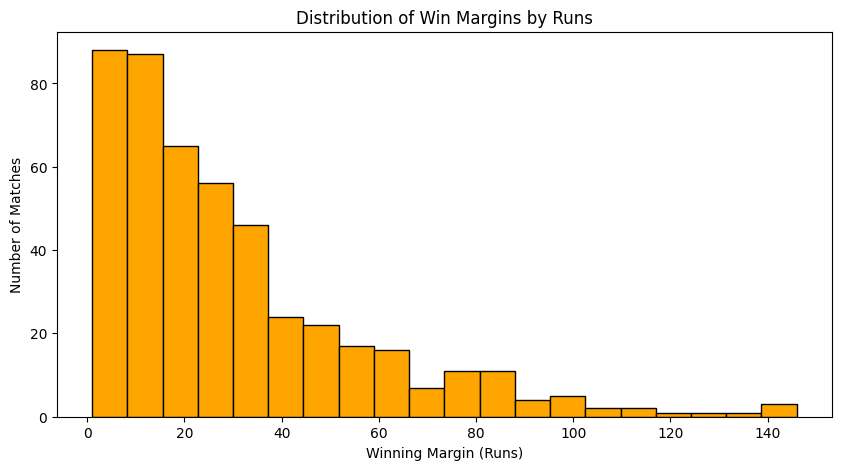

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    runs_win['result_margin'],
    bins=20,
    color='orange',
    edgecolor='black'
)

plt.title('Distribution of Win Margins by Runs')
plt.xlabel('Winning Margin (Runs)')
plt.ylabel('Number of Matches')

plt.show()

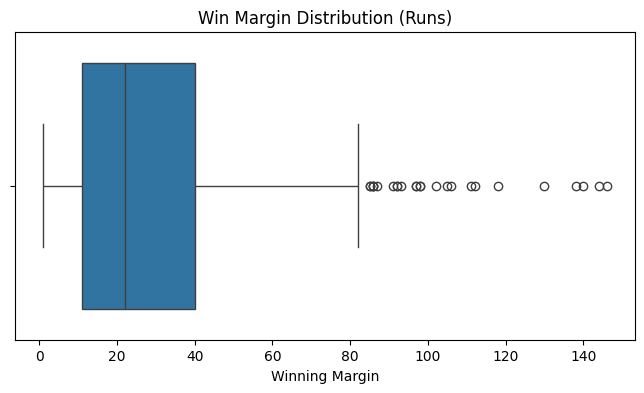

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(
    x=runs_win['result_margin']
)

plt.title('Win Margin Distribution (Runs)')
plt.xlabel('Winning Margin')

plt.show()